# Student Performance Indicator — Machine Learning Project

**Project:** Machine Learning Model Application on Student Performance
**Goal:** Predict a student's **Math Score** based on Gender, Ethnicity, Parental Level of Education, Lunch, Test Preparation Course, Reading Score, and Writing Score.

### Life Cycle of this ML Project
1. Understanding the Problem Statement
2. Data Collection
3. Data Checks to Perform
4. Exploratory Data Analysis (EDA)
5. Data Pre-Processing
6. Model Training
7. Choose the Best Model
8. Conclusion


## 1) Problem Statement

This project understands how a student's performance (test scores) is affected by other variables such as:
- Gender
- Ethnicity (Race/Group)
- Parental level of education
- Lunch type
- Test preparation course

We will predict **Math Score** as the target variable using the remaining features.


## 2) Data Collection

**Source:** [Kaggle - Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977)

The dataset consists of **8 columns and 1000 rows**.

**Column description:**
| Column | Description |
|---|---|
| gender | Sex of the student (male/female) |
| race/ethnicity | Ethnic group of the student (group A to E) |
| parental level of education | Parents' final education level |
| lunch | Type of lunch before the test (standard / free-reduced) |
| test preparation course | Whether the test prep course was completed |
| math score | Marks secured in Maths |
| reading score | Marks secured in Reading |
| writing score | Marks secured in Writing |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
print("Shape of the dataset:", df.shape)
df.info()

Shape of the dataset: (1000, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## 3) Data Checks to Perform

- Check missing values
- Check duplicates
- Check data types
- Check number of unique values in each column
- Check basic statistics


In [3]:
# Check missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [4]:
# Check duplicates
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [5]:
# Check unique values for each column
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values -> {df[col].unique() if df[col].dtype == 'object' else ''}")

gender: 2 unique values -> 
race/ethnicity: 5 unique values -> 
parental level of education: 6 unique values -> 
lunch: 2 unique values -> 
test preparation course: 2 unique values -> 
math score: 81 unique values -> 
reading score: 72 unique values -> 
writing score: 77 unique values -> 


In [6]:
# Statistical summary of numeric columns
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
# Add a derived column: total and average score (useful for EDA)
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average_score'] = df['total_score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


## 4) Exploratory Data Analysis (EDA)

We explore the distribution of scores and how categorical features relate to performance.


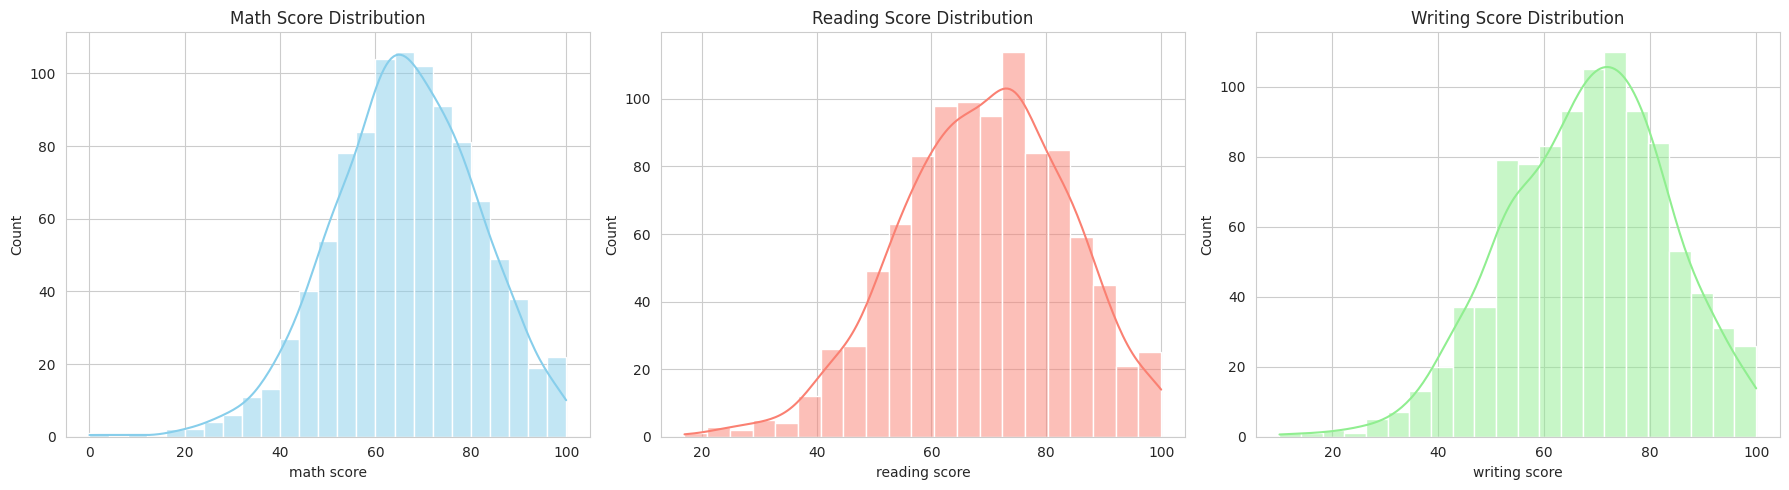

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['math score'], kde=True, ax=axs[0], color='skyblue')
axs[0].set_title('Math Score Distribution')
sns.histplot(df['reading score'], kde=True, ax=axs[1], color='salmon')
axs[1].set_title('Reading Score Distribution')
sns.histplot(df['writing score'], kde=True, ax=axs[2], color='lightgreen')
axs[2].set_title('Writing Score Distribution')
plt.tight_layout()
plt.show()

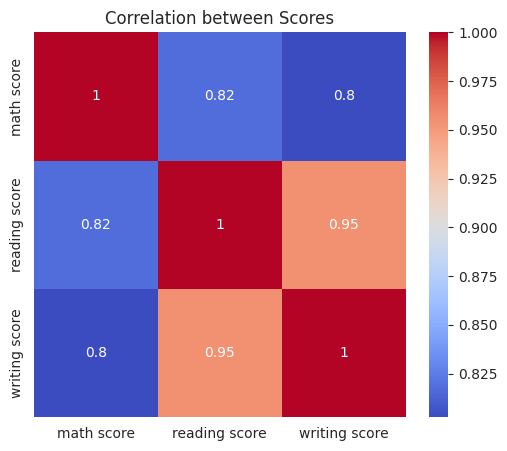

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Scores')
plt.show()

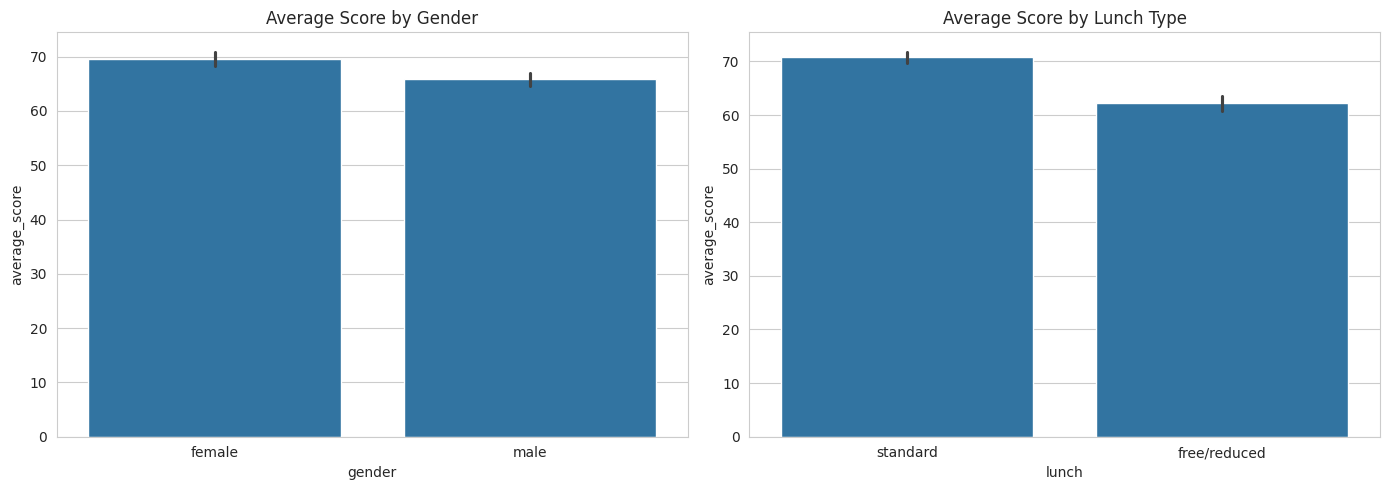

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='gender', y='average_score', ax=axs[0], estimator=np.mean)
axs[0].set_title('Average Score by Gender')
sns.barplot(data=df, x='lunch', y='average_score', ax=axs[1], estimator=np.mean)
axs[1].set_title('Average Score by Lunch Type')
plt.tight_layout()
plt.show()

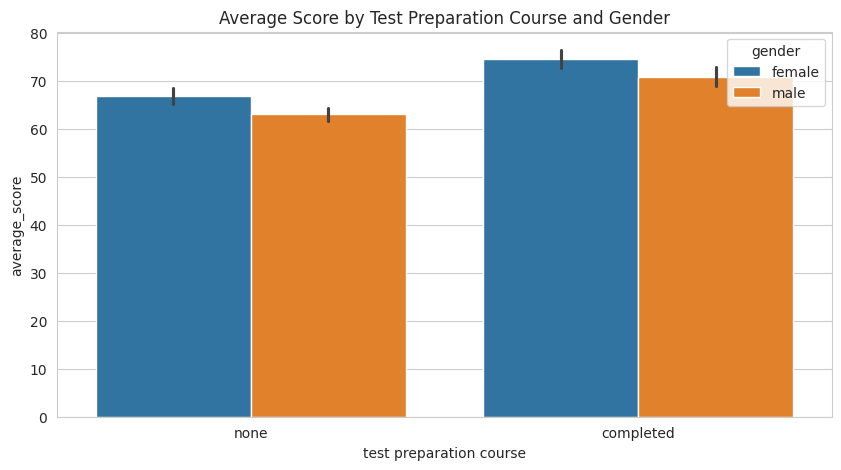

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='test preparation course', y='average_score', hue='gender', estimator=np.mean)
plt.title('Average Score by Test Preparation Course and Gender')
plt.show()

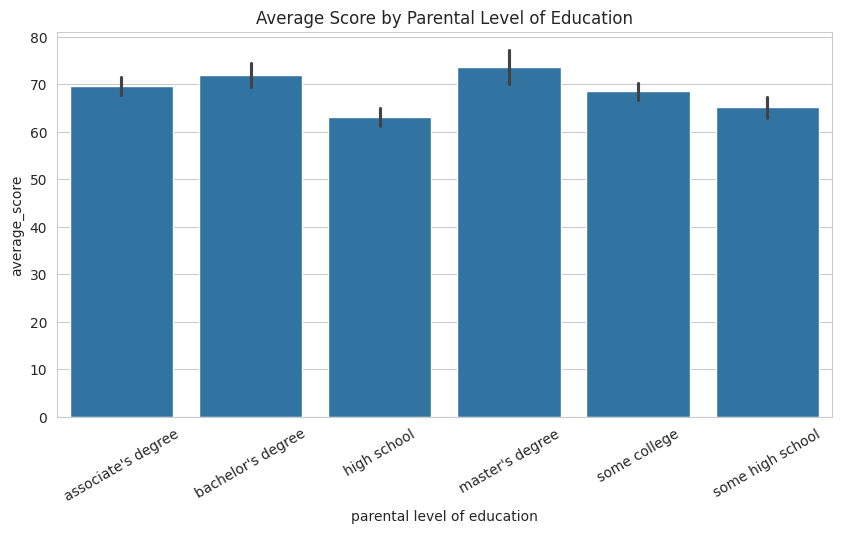

In [12]:
plt.figure(figsize=(10, 5))
order = sorted(df['parental level of education'].unique())
sns.barplot(data=df, x='parental level of education', y='average_score', order=order, estimator=np.mean)
plt.title('Average Score by Parental Level of Education')
plt.xticks(rotation=30)
plt.show()

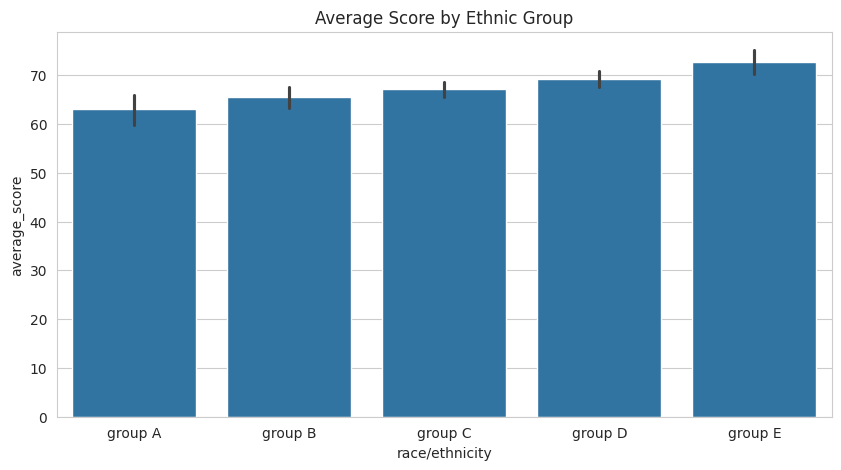

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='race/ethnicity', y='average_score', order=sorted(df['race/ethnicity'].unique()), estimator=np.mean)
plt.title('Average Score by Ethnic Group')
plt.show()

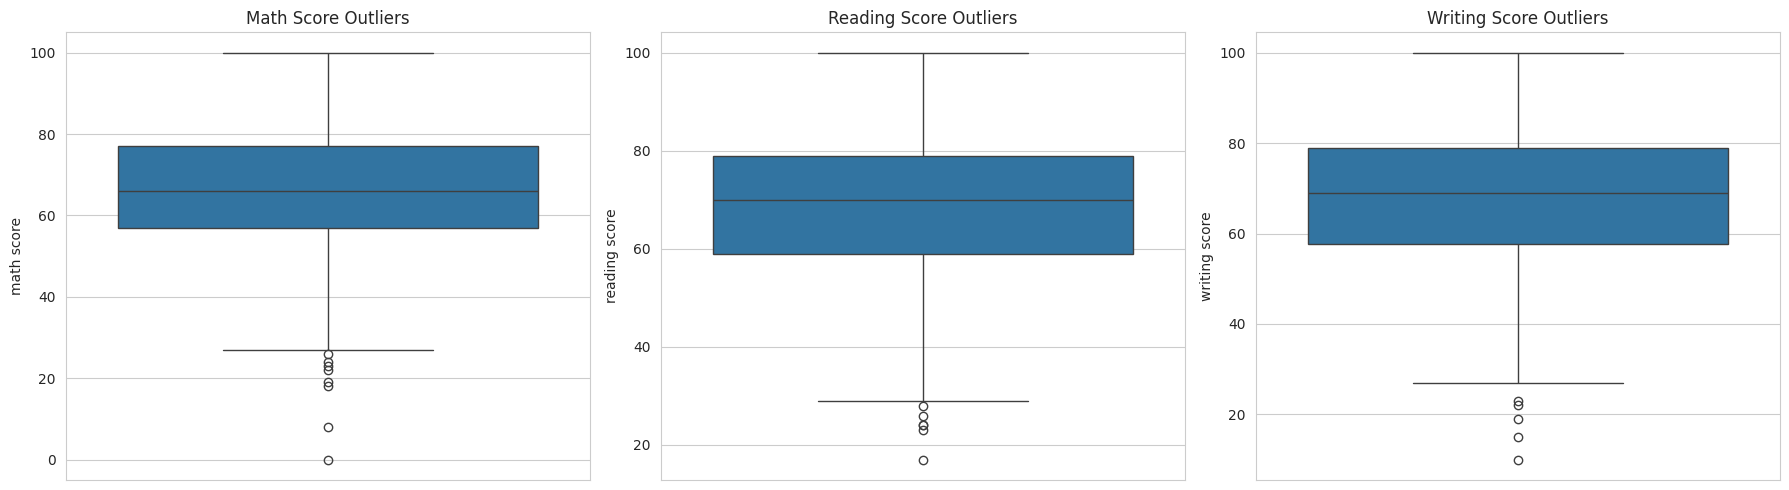

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, y='math score', ax=axs[0])
sns.boxplot(data=df, y='reading score', ax=axs[1])
sns.boxplot(data=df, y='writing score', ax=axs[2])
axs[0].set_title('Math Score Outliers')
axs[1].set_title('Reading Score Outliers')
axs[2].set_title('Writing Score Outliers')
plt.tight_layout()
plt.show()

**EDA Insights (typical for this dataset):**
- Female students tend to score higher on average than male students (driven by reading/writing).
- Students who completed the **test preparation course** generally score higher across all subjects.
- Students with **standard lunch** outperform those with free/reduced lunch.
- Higher parental education level is associated with slightly higher average scores.
- Reading and writing scores are very strongly correlated with each other, and moderately correlated with math score.


## 5) Data Pre-Processing

Steps:
1. Drop helper columns created for EDA (`total_score`, `average_score`) so they don't leak into the model as proxies for the target.
2. Separate features (X) and target (y = `math score`).
3. One-Hot Encode categorical columns.
4. Standard-scale numeric columns.
5. Train/test split.


In [15]:
# Define target and features
target = 'math score'

X = df.drop(columns=['math score', 'total_score', 'average_score'])
y = df['math score']

print("Features used:", list(X.columns))
X.head()

Features used: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'reading score', 'writing score']


,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

print("Numeric features:", list(num_features))
print("Categorical features:", list(cat_features))

preprocessor = ColumnTransformer(
    transformers=[
        ('OneHotEncoder', OneHotEncoder(drop='first'), cat_features),
        ('StandardScaler', StandardScaler(), num_features)
    ]
)

X_transformed = preprocessor.fit_transform(X)
print("Transformed feature matrix shape:", X_transformed.shape)

Numeric features: ['reading score', 'writing score']
Categorical features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
Transformed feature matrix shape: (1000, 14)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (800, 14)
X_test shape: (200, 14)


## 6) Model Training

We train multiple regression models and evaluate each using:
- **RMSE** (Root Mean Squared Error)
- **MAE** (Mean Absolute Error)
- **R² Score**


In [18]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

model_results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    model_results.append({
        'Model': name,
        'Train RMSE': train_rmse, 'Train MAE': train_mae, 'Train R2': train_r2,
        'Test RMSE': test_rmse, 'Test MAE': test_mae, 'Test R2': test_r2
    })

    print(f"{name}")
    print(f"  Train -> RMSE: {train_rmse:.4f} | MAE: {train_mae:.4f} | R2: {train_r2:.4f}")
    print(f"  Test  -> RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}")
    print('-' * 60)

Linear Regression
  Train -> RMSE: 5.3231 | MAE: 4.2667 | R2: 0.8743
  Test  -> RMSE: 5.3940 | MAE: 4.2148 | R2: 0.8804
------------------------------------------------------------
Ridge
  Train -> RMSE: 5.3235 | MAE: 4.2650 | R2: 0.8743
  Test  -> RMSE: 5.3936 | MAE: 4.2125 | R2: 0.8805
------------------------------------------------------------
Lasso
  Train -> RMSE: 6.5938 | MAE: 5.2063 | R2: 0.8071
  Test  -> RMSE: 6.5197 | MAE: 5.1579 | R2: 0.8253
------------------------------------------------------------
K-Neighbors Regressor
  Train -> RMSE: 5.5779 | MAE: 4.4588 | R2: 0.8620
  Test  -> RMSE: 7.3644 | MAE: 5.7130 | R2: 0.7771
------------------------------------------------------------
Decision Tree
  Train -> RMSE: 0.2795 | MAE: 0.0187 | R2: 0.9997
  Test  -> RMSE: 8.0855 | MAE: 6.4050 | R2: 0.7313
------------------------------------------------------------


Random Forest Regressor
  Train -> RMSE: 2.3226 | MAE: 1.8503 | R2: 0.9761
  Test  -> RMSE: 6.0650 | MAE: 4.7546 | R2: 0.8488
------------------------------------------------------------
AdaBoost Regressor
  Train -> RMSE: 5.8336 | MAE: 4.8090 | R2: 0.8491
  Test  -> RMSE: 6.0280 | MAE: 4.6404 | R2: 0.8507
------------------------------------------------------------
Gradient Boosting
  Train -> RMSE: 4.6772 | MAE: 3.7521 | R2: 0.9030
  Test  -> RMSE: 5.5720 | MAE: 4.3032 | R2: 0.8724
------------------------------------------------------------


## 7) Choose the Best Model

We compare all models on **Test R² Score** (higher is better — closer to 1.0 means the model explains more variance in math scores).


In [19]:
results_df = pd.DataFrame(model_results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
results_df

,Model,Train RMSE,Train MAE,Train R2,Test RMSE,Test MAE,Test R2
0,Ridge,5.323503,4.264992,0.874296,5.393586,4.212515,0.880451
1,Linear Regression,5.323051,4.266712,0.874317,5.393994,4.214763,0.880433
2,Gradient Boosting,4.677174,3.752072,0.902967,5.572022,4.303235,0.872410
3,AdaBoost Regressor,5.833603,4.809026,0.849052,6.028016,4.640384,0.850673
4,Random Forest Regressor,2.322562,1.850310,0.976073,6.065024,4.754576,0.848834
5,Lasso,6.593816,5.206303,0.807146,6.519695,5.157882,0.825320
6,K-Neighbors Regressor,5.577925,4.458750,0.861993,7.364360,5.713000,0.777126
7,Decision Tree,0.279508,0.018750,0.999653,8.085481,6.405000,0.731341


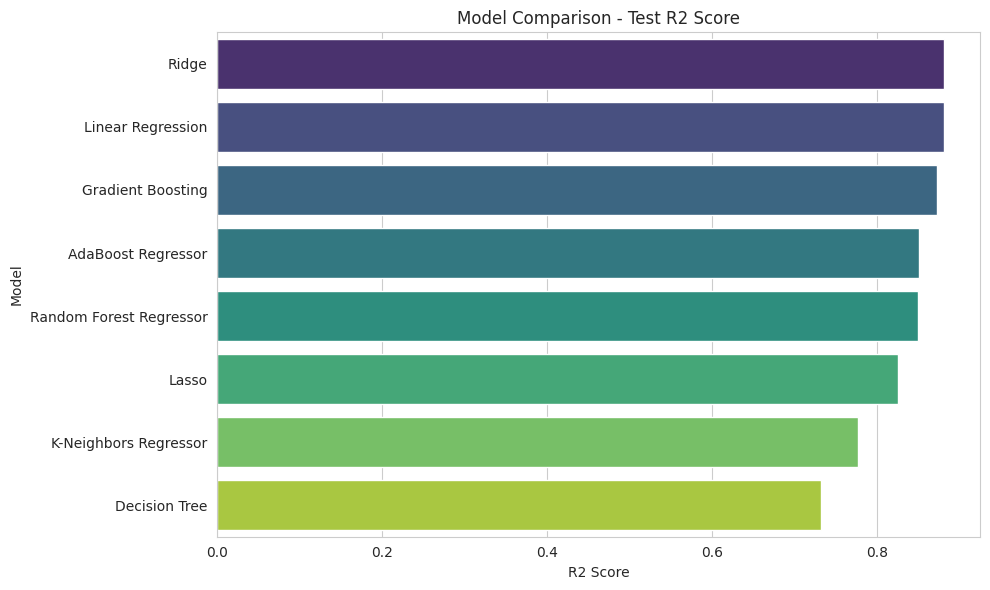

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Test R2', y='Model', palette='viridis')
plt.title('Model Comparison - Test R2 Score')
plt.xlabel('R2 Score')
plt.tight_layout()
plt.show()

In [21]:
best_model_name = results_df.iloc[0]['Model']
best_model_r2 = results_df.iloc[0]['Test R2']
print(f"Best Model: {best_model_name}")
print(f"Test R2 Score: {best_model_r2:.4f}")

best_model = models[best_model_name]

Best Model: Ridge
Test R2 Score: 0.8805


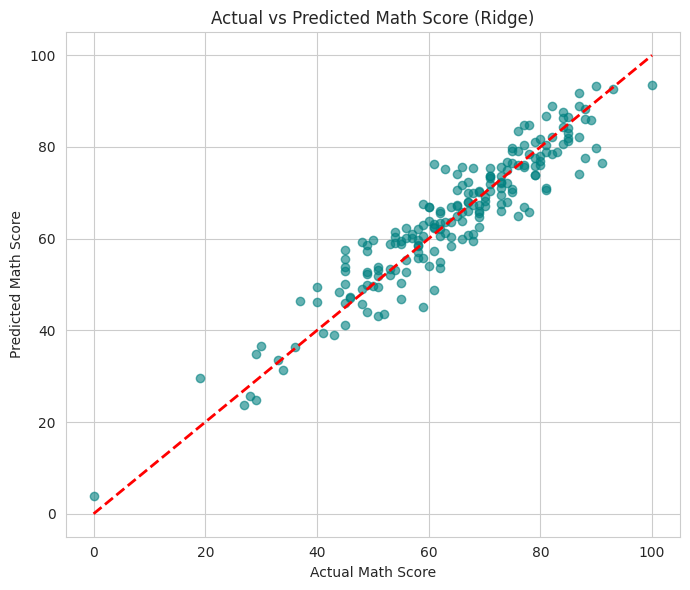

In [22]:
# Plot actual vs predicted for the best model
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title(f'Actual vs Predicted Math Score ({best_model_name})')
plt.tight_layout()
plt.show()

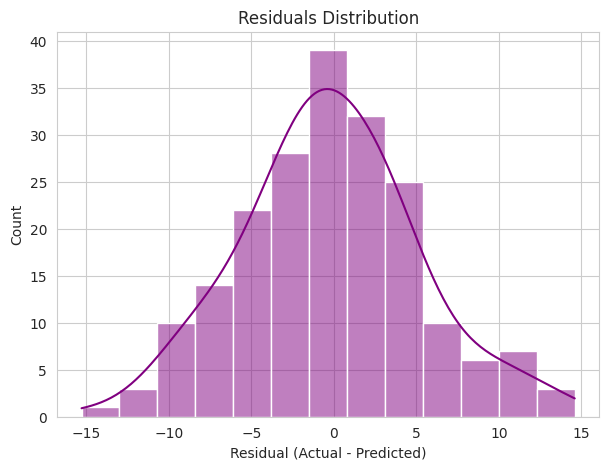

In [23]:
# Residuals plot
residuals = y_test - y_pred_best

plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.show()

## 8) Conclusion

- We performed the full ML lifecycle on the Student Performance dataset: problem understanding, data collection, data checks, EDA, preprocessing, model training, and model selection.
- Categorical features were one-hot encoded and numeric features standardized.
- Multiple regression models were trained and compared using RMSE, MAE, and R².
- The best-performing model (printed above) can be used to predict a student's math score from their demographic and academic profile.
- Key drivers of performance observed in EDA: **test preparation course completion**, **lunch type**, and **parental education level**, alongside the strong relationship between reading/writing and math scores.

### Next steps (optional extensions)
- Hyperparameter tuning (GridSearchCV / RandomizedSearchCV) on the best model.
- Try XGBoost / CatBoost for potentially better performance (requires `pip install xgboost catboost`).
- Save the trained pipeline (preprocessor + model) with `pickle` for deployment.
